# Notebook 1 — Machine Learning Fundamentals
### Sprint 7 | Machine Learning Fundamentals for AI/ML Engineers

**Methodology:** Understand → Demonstrate → Implement → Interpret, continuing with
the Telco Customer Churn dataset (engineered per Sprint 6) for classification, and
introducing the California Housing dataset for regression, since Telco has no natural
continuous target.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

housing = pd.read_csv("california_housing.csv")

print(f"Classification dataset (Telco): {df.shape[0]:,} rows, target = Churn (binary)")
print(f"Regression dataset (California Housing): {housing.shape[0]:,} rows, target = median_house_value (continuous)")


Classification dataset (Telco): 7,043 rows, target = Churn (binary)
Regression dataset (California Housing): 20,640 rows, target = median_house_value (continuous)


---
## 1. What is Machine Learning?

### Understand
Machine Learning is the practice of having a program learn a pattern from data, rather
than being explicitly programmed with hand-written rules for every case — the program
improves at a task through exposure to examples, not through a developer enumerating
every possible rule.

### Demonstrate
**Direct example from this sprint's own data:** a hand-written rule like "if Contract is
Month-to-month AND InternetService is Fiber optic, predict churn" (Sprint 4's manually
discovered insight) is NOT machine learning — it's a human-derived business rule. A
model that discovers this same pattern (and others) automatically from thousands of
examples, without being told the rule explicitly, IS machine learning.


---
## 2. Supervised vs. 3. Unsupervised vs. 4. Reinforcement Learning

### Understand
- **Supervised learning**: learns from labeled examples (input → known correct output).
  Both datasets in this sprint are supervised: Telco has `Churn`, Housing has
  `median_house_value`.
- **Unsupervised learning**: finds structure in UNlabeled data (no "correct answer"
  given) — e.g., clustering customers into segments without being told what the segments
  should be (Notebook 15).
- **Reinforcement learning**: an agent learns by taking actions and receiving
  rewards/penalties over time — not directly demonstrated in this sprint (neither
  dataset has a sequential-decision structure), but worth distinguishing clearly.

### Implement


In [2]:
print("Telco dataset -> SUPERVISED (Churn is a known, labeled outcome for every row)")
print("California Housing -> SUPERVISED (median_house_value is a known, labeled outcome)")
print("\nIf we instead asked 'find natural customer segments in Telco, with no Churn label used',")
print("that would become UNSUPERVISED learning — demonstrated directly in Notebook 15 (Clustering).")


Telco dataset -> SUPERVISED (Churn is a known, labeled outcome for every row)
California Housing -> SUPERVISED (median_house_value is a known, labeled outcome)

If we instead asked 'find natural customer segments in Telco, with no Churn label used',
that would become UNSUPERVISED learning — demonstrated directly in Notebook 15 (Clustering).


---
## 5. Classification vs. 6. Regression

### Understand
Both are supervised learning, distinguished by the TARGET's type: **classification**
predicts a category (Telco's `Churn`: Yes/No); **regression** predicts a continuous
number (Housing's `median_house_value`: a dollar amount).

### Implement


In [3]:
print(f"Churn dtype: {df['Churn'].dtype}, unique values: {df['Churn'].unique()} -> CLASSIFICATION")
print(f"median_house_value dtype: {housing['median_house_value'].dtype}, "
      f"range: {housing['median_house_value'].min():.0f} to {housing['median_house_value'].max():.0f} -> REGRESSION")


Churn dtype: str, unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str -> CLASSIFICATION
median_house_value dtype: float64, range: 14999 to 500001 -> REGRESSION


---
## 7. Structured vs. 8. Unstructured Data (Recap)

### Understand
(Recap from Sprint 2, Notebook 1) Both datasets in this sprint are structured
(rows/columns, clean schema) — this sprint's algorithms all assume structured tabular
input, unlike deep learning approaches built for unstructured data (images, raw text).


---
## 9. The Machine Learning Workflow

### Understand
This sprint follows: **Problem Definition → Data Collection (Sprints 4-6) → Model
Selection → Training → Evaluation → Deployment** — the first three stages are
already complete from prior sprints; this sprint focuses specifically on Model
Selection, Training, and Evaluation.

### Implement


In [4]:
workflow = {
    'Problem Definition': 'Predict customer churn (classification); predict house value (regression)',
    'Data Collection & Preparation': 'Sprints 4 (EDA), 5 (Cleaning), 6 (Feature Engineering) — already complete',
    'Model Selection': 'Notebooks 3-14 of THIS sprint (regression, classification, trees, ensembles, SVM, etc.)',
    'Training': 'Fitting each model on the training split',
    'Evaluation': 'Notebooks 16-17 (classification & regression metrics)',
    'Deployment': 'Outside this sprint\'s scope — would follow Sprint 5\'s Pipeline pattern',
}
for stage, detail in workflow.items():
    print(f"{stage:<28}: {detail}")


Problem Definition          : Predict customer churn (classification); predict house value (regression)
Data Collection & Preparation: Sprints 4 (EDA), 5 (Cleaning), 6 (Feature Engineering) — already complete
Model Selection             : Notebooks 3-14 of THIS sprint (regression, classification, trees, ensembles, SVM, etc.)
Training                    : Fitting each model on the training split
Evaluation                  : Notebooks 16-17 (classification & regression metrics)
Deployment                  : Outside this sprint's scope — would follow Sprint 5's Pipeline pattern


---
## 10. Training Data, Validation Data, Test Data (Recap)

### Understand
(Recap from Sprint 5, Notebooks 1 & 12) Every model in this sprint will be trained on a
TRAINING split, and evaluated on a held-out TEST split it never saw during fitting —
this discipline doesn't relax just because we're now training real models instead of
just preprocessing.

### Implement


In [5]:
from sklearn.model_selection import train_test_split

X_clf = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y_clf = df['Churn_numeric']
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)
print(f"Classification split -> Train: {len(X_train_clf):,} | Test: {len(X_test_clf):,}")

X_reg = housing[['median_income', 'housing_median_age', 'total_rooms']]
y_reg = housing['median_house_value']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print(f"Regression split -> Train: {len(X_train_reg):,} | Test: {len(X_test_reg):,}")


Classification split -> Train: 5,634 | Test: 1,409
Regression split -> Train: 16,512 | Test: 4,128


---
## 11. Model Parameters vs. 12. Hyperparameters

### Understand
**Parameters** are LEARNED by the model during training (e.g., a linear regression's
coefficients) — you never set these by hand. **Hyperparameters** are CHOSEN by the
engineer BEFORE training (e.g., a decision tree's `max_depth`) — they control how the
model learns, not what it learns.

### Implement


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression().fit(X_train_reg, y_train_reg)
print(f"LEARNED parameters (coefficients): {dict(zip(X_reg.columns, lr.coef_.round(2)))}")
print(f"LEARNED parameter (intercept): {lr.intercept_:.2f}")

dt = DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42)   # both HYPERPARAMETERS, chosen by us
print(f"\nCHOSEN hyperparameters: max_depth={dt.max_depth}, min_samples_leaf={dt.min_samples_leaf}")


LEARNED parameters (coefficients): {'median_income': np.float64(42653.33), 'housing_median_age': np.float64(1975.74), 'total_rooms': np.float64(3.85)}
LEARNED parameter (intercept): -25029.51

CHOSEN hyperparameters: max_depth=3, min_samples_leaf=10


---
## 13. Bias-Variance Tradeoff

### Understand
**Bias** is error from a model being too SIMPLE to capture the true pattern
(underfitting). **Variance** is error from a model being too SENSITIVE to the specific
training data it saw (overfitting) — fitting noise, not signal. The tradeoff: reducing
one often increases the other; the goal is the sweet spot that minimizes TOTAL error on
new, unseen data.

### Demonstrate


In [7]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# A very simple model (high bias, low variance)
simple_model = LinearRegression().fit(X_train_reg, y_train_reg)
simple_train_error = root_mean_squared_error(y_train_reg, simple_model.predict(X_train_reg))
simple_test_error = root_mean_squared_error(y_test_reg, simple_model.predict(X_test_reg))

# A very complex, unconstrained tree (low bias, high variance)
complex_model = DecisionTreeRegressor(max_depth=None, random_state=42).fit(X_train_reg, y_train_reg)
complex_train_error = root_mean_squared_error(y_train_reg, complex_model.predict(X_train_reg))
complex_test_error = root_mean_squared_error(y_test_reg, complex_model.predict(X_test_reg))

print(f"Simple model (Linear Regression)  -> Train RMSE: {simple_train_error:,.0f} | Test RMSE: {simple_test_error:,.0f}")
print(f"Complex model (unrestricted Tree) -> Train RMSE: {complex_train_error:,.0f} | Test RMSE: {complex_test_error:,.0f}")


Simple model (Linear Regression)  -> Train RMSE: 80,335 | Test RMSE: 81,013
Complex model (unrestricted Tree) -> Train RMSE: 0 | Test RMSE: 109,741


**Finding:** The unrestricted tree achieves a training RMSE of **$0** — it has
perfectly memorized every training example — while its test RMSE ($109,741) is actually
**worse** than the simple linear model's ($81,013), despite linear regression having
much higher training error ($80,335, barely different from its own test error). This is
the bias-variance tradeoff in its starkest form: the complex model's low bias on
training data doesn't translate to real predictive power, because its variance
(sensitivity to the specific training rows it memorized) dominates on new data. Neither
extreme wins — this exact tradeoff motivates ensembles (Notebooks 12-13) and
regularization, covered throughout this sprint.


---
## 14. Overfitting vs. 15. Underfitting (Recap in This Context)

### Understand
Directly demonstrated above: the complex tree OVERFITS (low train error, much higher
test error); a model that's too simple would UNDERFIT (high error on both train AND
test). The goal is neither — it's the model complexity that minimizes TEST error
specifically.

### Implement — Visualizing the Tradeoff


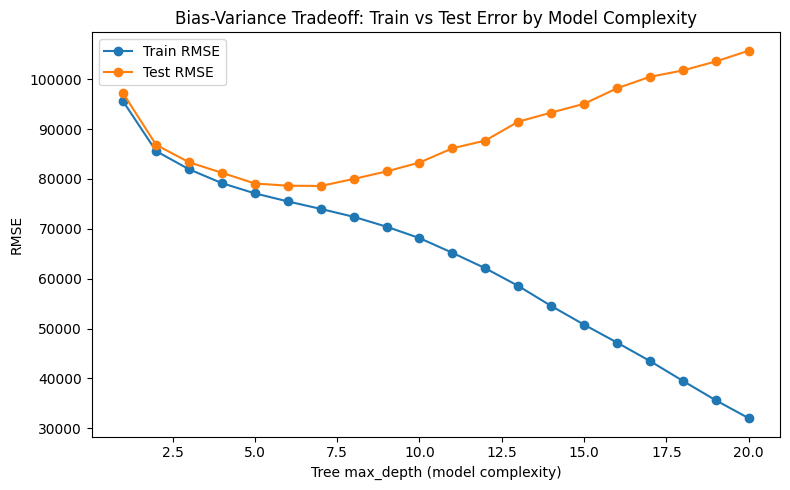

Test error is minimized at max_depth=7 — deeper than this starts overfitting.


In [8]:
import matplotlib.pyplot as plt
depths = range(1, 21)
train_errors, test_errors = [], []
for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train_reg, y_train_reg)
    train_errors.append(root_mean_squared_error(y_train_reg, model.predict(X_train_reg)))
    test_errors.append(root_mean_squared_error(y_test_reg, model.predict(X_test_reg)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_errors, label='Train RMSE', marker='o')
plt.plot(depths, test_errors, label='Test RMSE', marker='o')
plt.xlabel('Tree max_depth (model complexity)')
plt.ylabel('RMSE')
plt.title('Bias-Variance Tradeoff: Train vs Test Error by Model Complexity')
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depths[np.argmin(test_errors)]
print(f"Test error is minimized at max_depth={best_depth} — deeper than this starts overfitting.")


---
## Summary

| Concept | This Sprint's Demonstration |
|---|---|
| Supervised vs Unsupervised | Telco/Housing (labeled) vs. Notebook 15's clustering (unlabeled) |
| Classification vs Regression | Churn (Yes/No) vs. median_house_value ($) |
| Parameters vs Hyperparameters | Linear regression's learned coefficients vs. a tree's chosen `max_depth` |
| Bias-Variance Tradeoff | Linear regression (higher bias) vs. unrestricted tree (higher variance), shown numerically |
| Train/Test Discipline | Every model in this sprint evaluated on a genuinely held-out split |

**Next notebook:** `02_ML_Algorithms_Overview.ipynb` — a map of every algorithm this
sprint covers, and which problem type each is suited for.
